# Feature Selection & Dimensionality Optimization

In [2]:
# imports 

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from catboost import CatBoostClassifier

import shap 


In [3]:
# Create Engineered Dataset

from src.preprocessing import PreprocessConfig, preprocess_train_test
from src.features import FeatureConfig, engineer_train_test_features

# Load raw data
TRAIN_PATH = "D:\\dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n\\Train.csv"
TEST_PATH  = "D:\\dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n\\Test.csv"

train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)

# Initiliaze configs
pre_cfg = PreprocessConfig(
    id_col="ID",
    target_col="Target"
)

feat_cfg = FeatureConfig(
    id_col="ID",
    target_col="Target"
)

#run preprocessing
train_clean, test_clean = preprocess_train_test(
    train_raw,
    test_raw,
    pre_cfg,
    for_model="lightgbm"  # We use "lightgbm" here because the output is fully numeric, which is easier for: correlation analysis, SHAP & feature importance
)

# Run feature engineering
train_fe, test_fe = engineer_train_test_features(
    train_clean,
    test_clean,
    feat_cfg,
    collapse_rare_for_non_catboost=True
)

In [4]:
# Save the Engineered Dataset

import os

os.makedirs("data/processed", exist_ok=True)

train_fe.to_csv("data/processed/train_engineered.csv", index=False)
test_fe.to_csv("data/processed/test_engineered.csv", index=False)

print("Engineered datasets saved.")

Engineered datasets saved.


In [5]:
# Load feature selection

train_df = pd.read_csv("data/processed/train_engineered.csv")

TARGET = "Target"
ID = "ID"

X = train_df.drop(columns=[TARGET, ID])
y = train_df[TARGET]

feature_names = X.columns.tolist()

print("Feature count:", len(feature_names))

Feature count: 117


In [6]:
# Cross-Validation Setup

N_SPLITS = 5

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

Train Baseline Models to Collect Feature Importance. We collect feature importance across folds to measure stability.

In [7]:
X.dtypes.value_counts()

float64    55
str        44
int64      18
Name: count, dtype: int64

In [8]:
bad_cols = X.select_dtypes(include=["object"]).columns
print(len(bad_cols))
print(bad_cols)

44
Index(['country', 'attitude_stable_business_environment',
       'attitude_worried_shutdown', 'compliance_income_tax',
       'perception_insurance_doesnt_cover_losses',
       'perception_cannot_afford_insurance', 'motor_vehicle_insurance',
       'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone',
       'owner_sex', 'offers_credit_to_customers',
       'attitude_satisfied_with_achievement', 'has_credit_card',
       'keeps_financial_records',
       'perception_insurance_companies_dont_insure_businesses_like_yours',
       'perception_insurance_important', 'has_insurance',
       'covid_essential_service', 'attitude_more_successful_next_year',
       'problem_sourcing_money', 'marketing_word_of_mouth', 'has_loan_account',
       'has_internet_banking', 'has_debit_card', 'future_risk_theft_stock',
       'medical_insurance', 'funeral_insurance', 'motivation_make_more_money',
       'uses_friends_family_savings', 'uses_informal_lender',
       'business_age_bucket', '

C:\Users\otsyu\AppData\Local\Temp\ipykernel_17384\1907510790.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  bad_cols = X.select_dtypes(include=["object"]).columns


In [9]:
cat_cols = X.select_dtypes(include=["object"]).columns

for col in cat_cols:
    X[col] = X[col].astype("category")

C:\Users\otsyu\AppData\Local\Temp\ipykernel_17384\88062776.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns


In [10]:
X.dtypes.value_counts()

float64     55
int64       18
category    10
category     9
category     7
category     2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

 **LightGBM feature importance**

In [11]:


# Identify categorical columns
cat_cols = X.select_dtypes(include=["category"]).columns.tolist()

lgb_importances = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=1200,
        learning_rate=0.02,
        num_leaves=128,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="multi_logloss",
        categorical_feature=cat_cols
    )

    lgb_importances.append(model.feature_importances_)

# aggregate & Convert to dataframe

lgb_importances = np.array(lgb_importances)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": lgb_importances.mean(axis=0)
}).sort_values("importance", ascending=False)

importance_df.head(30)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017431 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4085
[LightGBM] [Info] Number of data points in the train set: 7694, number of used features: 114
[LightGBM] [Info] Start training from score -3.018607
[LightGBM] [Info] Start training from score -0.426214
[LightGBM] [Info] Start training from score -1.210144
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

,feature,importance
1,owner_age,32324.2
88,expenses_to_personal_income,28697.8
87,turnover_to_personal_income,27434.8
7,personal_income,22656.6
85,expense_ratio,22323.0
8,business_expenses,22245.4
84,margin_proxy,19756.6
43,business_age_total_months,18236.0
9,business_turnover,17840.4
86,turnover_to_expenses,17723.6


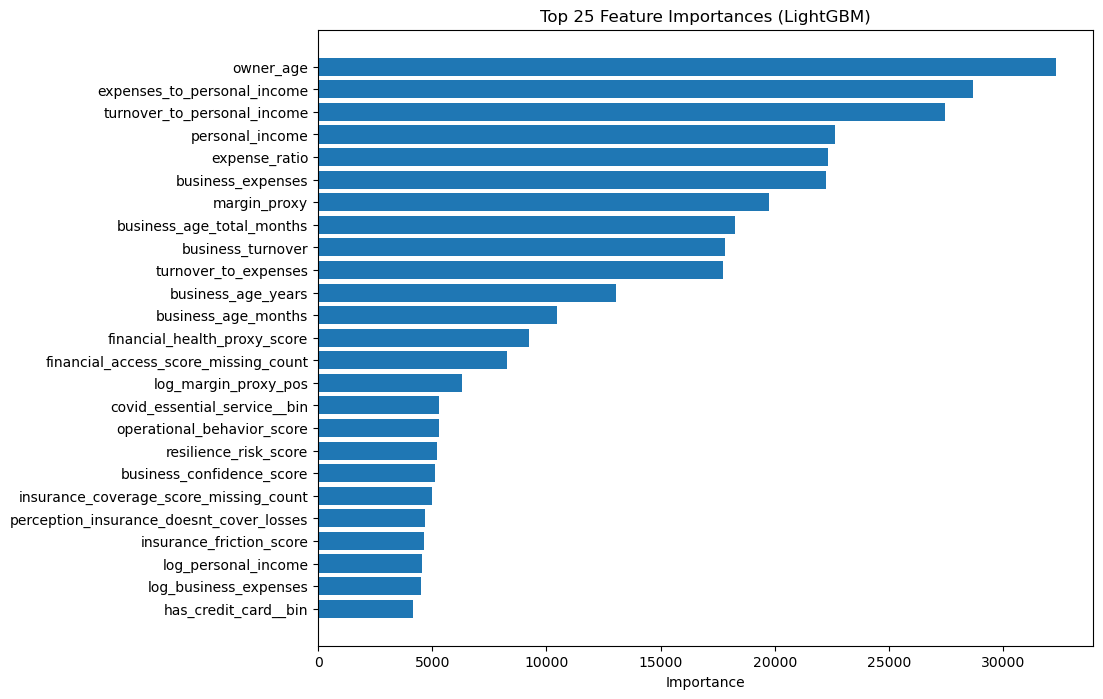

In [12]:
# Visualize top features 

import matplotlib.pyplot as plt

top_n = 25

plt.figure(figsize=(10,8))

plt.barh(
    importance_df.head(top_n)["feature"][::-1],
    importance_df.head(top_n)["importance"][::-1]
)

plt.title("Top 25 Feature Importances (LightGBM)")
plt.xlabel("Importance")
plt.show()

In [13]:
# reduce feature set

top_features = importance_df.head(80)["feature"].tolist()

X_reduced = X[top_features]

print("Original features:", X.shape[1])
print("Reduced features:", X_reduced.shape[1])

Original features: 117
Reduced features: 80


**CatBoost Feature Importance**

In [14]:
cat_importances = []

cat_cols = X.select_dtypes(include=["category"]).columns.tolist()

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=1500,
        learning_rate=0.03,
        depth=8,
        loss_function="MultiClass",
        eval_metric="TotalF1",
        verbose=False,
        random_seed=42
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_cols   # ← IMPORTANT
    )

    cat_importances.append(model.get_feature_importance())

In [15]:
# Aggregate feature Importance

cat_importances = np.array(cat_importances)

cat_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": cat_importances.mean(axis=0)
}).sort_values("importance", ascending=False)

cat_importance_df.head(30)

,feature,importance
33,funeral_insurance,26.528373
35,uses_friends_family_savings,3.612359
27,has_loan_account,3.592212
18,has_credit_card,3.194612
29,has_debit_card,2.935347
22,has_insurance,2.708297
47,has_credit_card__bin,2.426901
107,country_x_has_loan_account,1.993100
32,medical_insurance,1.933348
11,motor_vehicle_insurance,1.710476


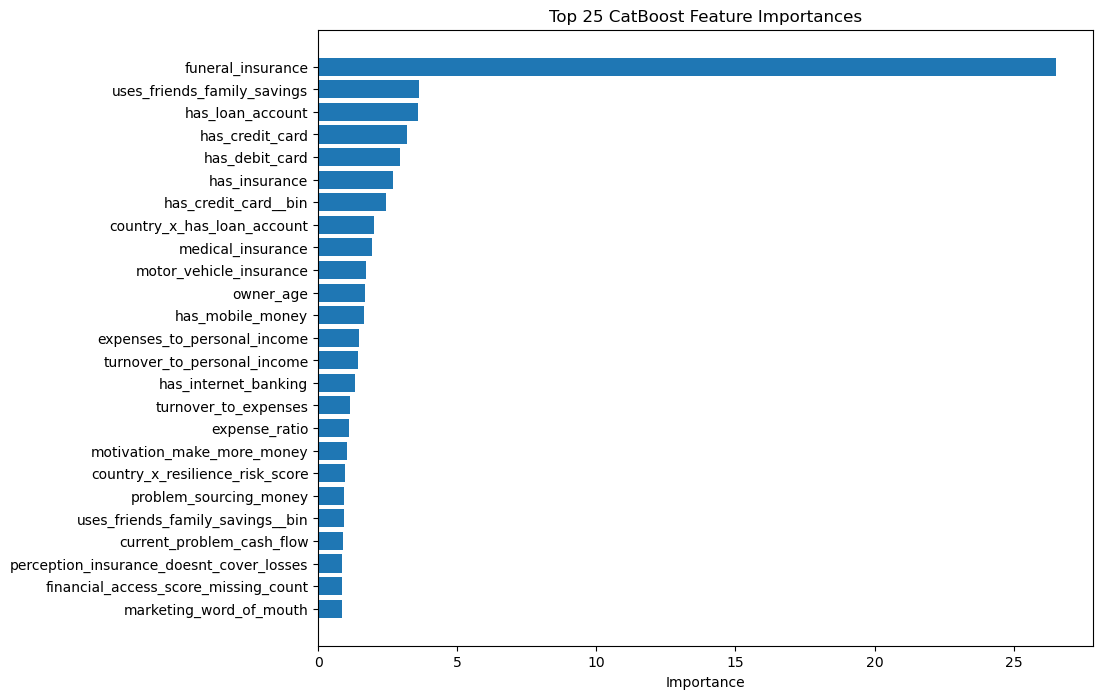

In [16]:
# Plot feature importance

top_n = 25

plt.figure(figsize=(10,8))

plt.barh(
    cat_importance_df.head(top_n)["feature"][::-1],
    cat_importance_df.head(top_n)["importance"][::-1]
)

plt.title("Top 25 CatBoost Feature Importances")
plt.xlabel("Importance")

plt.show()

**Consensus ranking**

Final Importance =
    0.5 * LightGBM importance + 0.5 * CatBoost importance

In [17]:
combined_importance = importance_df.merge(
    cat_importance_df,
    on="feature",
    suffixes=("_lgb","_cat")
)

combined_importance["combined"] = (
    combined_importance["importance_lgb"] +
    combined_importance["importance_cat"]
) / 2

combined_importance = combined_importance.sort_values(
    "combined",
    ascending=False
)

In [18]:
combined_importance.head(50)

,feature,importance_lgb,importance_cat,combined
0,owner_age,32324.2,1.684333,16162.942167
1,expenses_to_personal_income,28697.8,1.477234,14349.638617
2,turnover_to_personal_income,27434.8,1.451915,13718.125958
3,personal_income,22656.6,0.672513,11328.636257
4,expense_ratio,22323.0,1.097443,11162.048721
5,business_expenses,22245.4,0.745007,11123.072503
6,margin_proxy,19756.6,0.563902,9878.581951
7,business_age_total_months,18236.0,0.701785,9118.350893
8,business_turnover,17840.4,0.562611,8920.481306
9,turnover_to_expenses,17723.6,1.150925,8862.375462


### Permutation feature importance

In [19]:
# Setup

from sklearn.inspection import permutation_importance

In [20]:
# Train Base LightGBM model

lgb_model = lgb.LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.02,
    num_leaves=128,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [21]:
# Compute Permutation Importance

perm_importances = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    lgb_model.fit(
        X_train,
        y_train,
        categorical_feature=cat_cols
    )

    result = permutation_importance(
        lgb_model,
        X_val,
        y_val,
        scoring="f1_macro",
        n_repeats=5,
        random_state=42
    )

    perm_importances.append(result.importances_mean)

perm_importances = np.array(perm_importances)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001471 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4085
[LightGBM] [Info] Number of data points in the train set: 7694, number of used features: 114
[LightGBM] [Info] Start training from score -3.018607
[LightGBM] [Info] Start training from score -0.426214
[LightGBM] [Info] Start training from score -1.210144
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

In [22]:
# Aggregate Importance

perm_df = pd.DataFrame({
    "feature": X.columns,
    "perm_importance": perm_importances.mean(axis=0)
}).sort_values("perm_importance", ascending=False)

perm_df.head(30)

,feature,perm_importance
33,funeral_insurance,0.071834
47,has_credit_card__bin,0.068279
57,insurance_coverage_score_missing_count,0.059572
49,has_loan_account__bin,0.053362
107,country_x_has_loan_account,0.019500
22,has_insurance,0.016020
70,attitude_more_successful_next_year__bin,0.010083
51,financial_access_score_missing_count,0.009284
83,perception_insurance_important__bin,0.006699
18,has_credit_card,0.005554


### Correlation Pruning

Highly correlated features cause:

+ redundant signal
+ model instability
+ overfitting

In [23]:
#separate numeric features
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

# Compute correlation matrix only on numeric data
corr_matrix = X[numeric_cols].corr().abs()

In [24]:
# Identify highly correlated pairs

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.9)
]

In [25]:
# Drop rendudant features

X_corr_pruned = X.drop(columns=to_drop)

print("Number of features dropped:", len(to_drop))
print("Remaining features:", X_corr_pruned.shape[1])

Number of features dropped: 12
Remaining features: 105


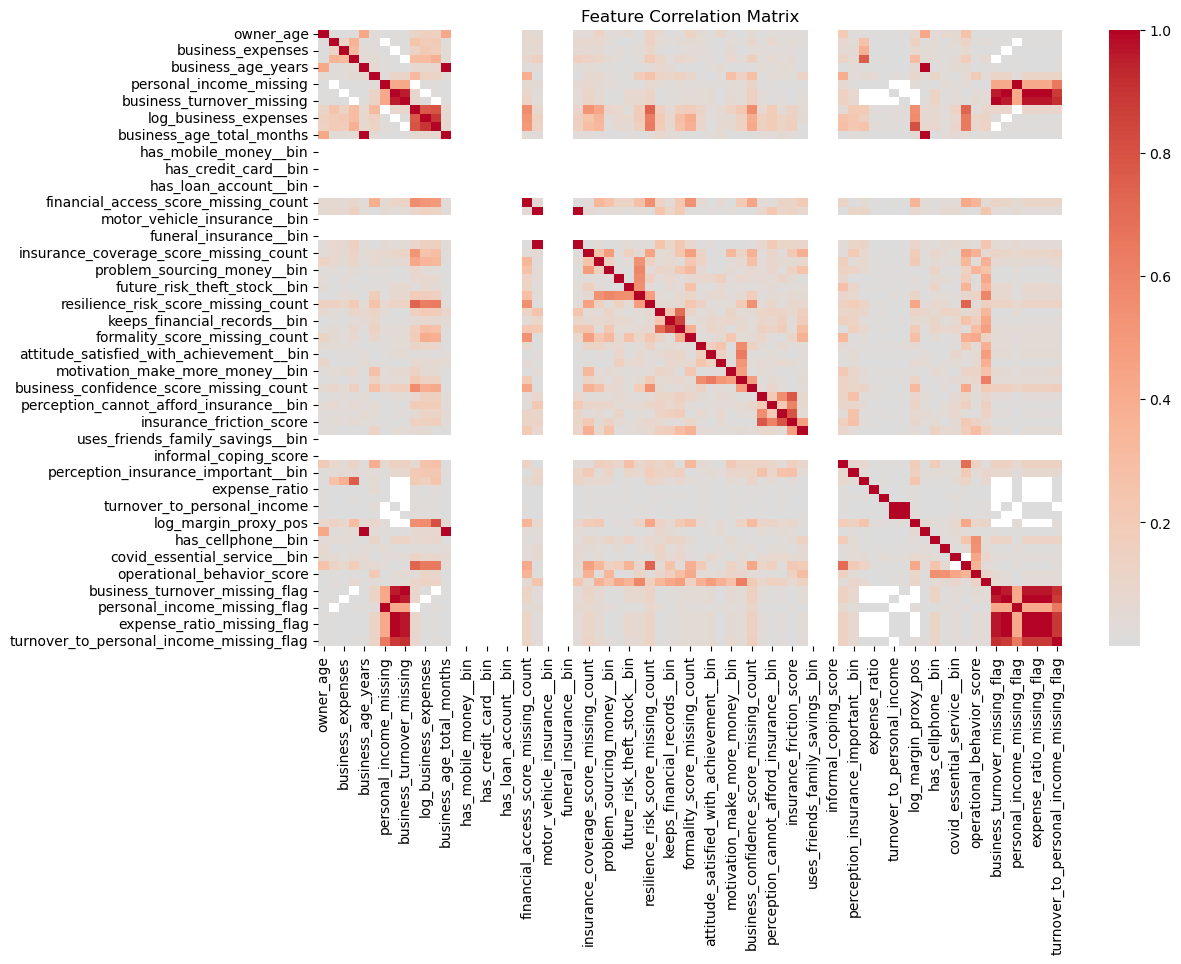

In [26]:
# Visualize

plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)
plt.title("Feature Correlation Matrix")
plt.show()

### SHAP Feature Importance

SHAP reveals true contribution to predictions

In [27]:
# Train model for SHAP

shap_model = lgb.LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.02,
    num_leaves=128,
    random_state=42
)

shap_model.fit(
    X_corr_pruned,
    y,
    categorical_feature=cat_cols
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009024 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3334
[LightGBM] [Info] Number of data points in the train set: 9618, number of used features: 102
[LightGBM] [Info] Start training from score -3.018659
[LightGBM] [Info] Start training from score -0.426266
[LightGBM] [Info] Start training from score -1.210021
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

,boosting_type,'gbdt'
,num_leaves,128
,max_depth,-1
,learning_rate,0.02
,n_estimators,1200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [28]:
# Compute SHAP values

explainer = shap.TreeExplainer(shap_model)

shap_values = explainer.shap_values(X_corr_pruned)

In [29]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[0].shape)

<class 'numpy.ndarray'>
9618
(105, 3)


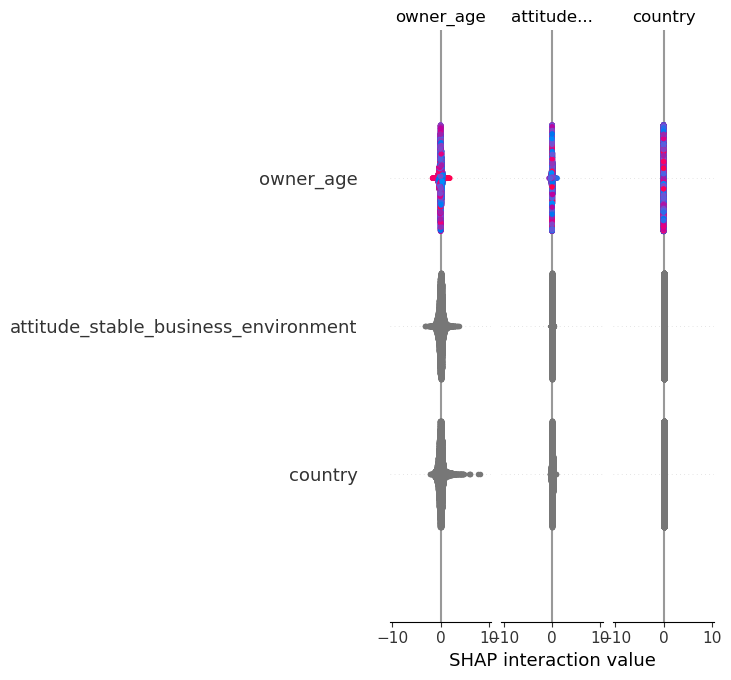

In [30]:
# Global feature importance

shap.summary_plot(
    shap_values,
    X_corr_pruned
)

In [31]:
# Convert to numpy array

shap_values = np.array(shap_values)

In [32]:
# Compute global importance

shap_importance = np.abs(shap_values).mean(axis=(0,2))

In [33]:
print(len(X_corr_pruned.columns))
print(len(shap_importance))

105
105


In [34]:
# Create SHAP importnce table 

shap_df = pd.DataFrame({
    "feature": X_corr_pruned.columns,
    "shap_importance": shap_importance
}).sort_values("shap_importance", ascending=False)

In [35]:
shap_df.head(20)

,feature,shap_importance
33,funeral_insurance,1.088572
54,insurance_coverage_score_missing_count,0.662790
102,country_x_has_loan_account,0.530956
49,financial_access_score_missing_count,0.434679
80,perception_insurance_important__bin,0.300338
45,has_credit_card__bin,0.261696
47,has_loan_account__bin,0.246808
22,has_insurance,0.241308
84,turnover_to_personal_income,0.193750
7,personal_income,0.190400


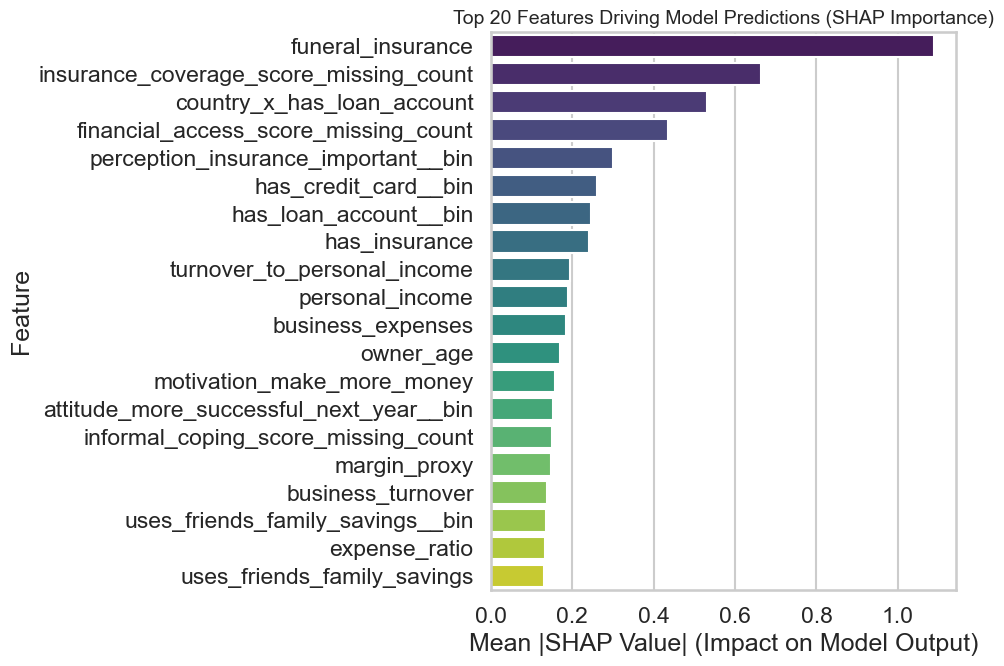

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("talk")

top = shap_df.head(20)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top,
    y="feature",
    x="shap_importance",
    hue="feature",        # assign hue
    palette="viridis",
    dodge=False,
    legend=False
)
plt.title("Top 20 Features Driving Model Predictions (SHAP Importance)", fontsize=14)
plt.xlabel("Mean |SHAP Value| (Impact on Model Output)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [37]:
# save plot

plt.savefig(
    "top_shap_features.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

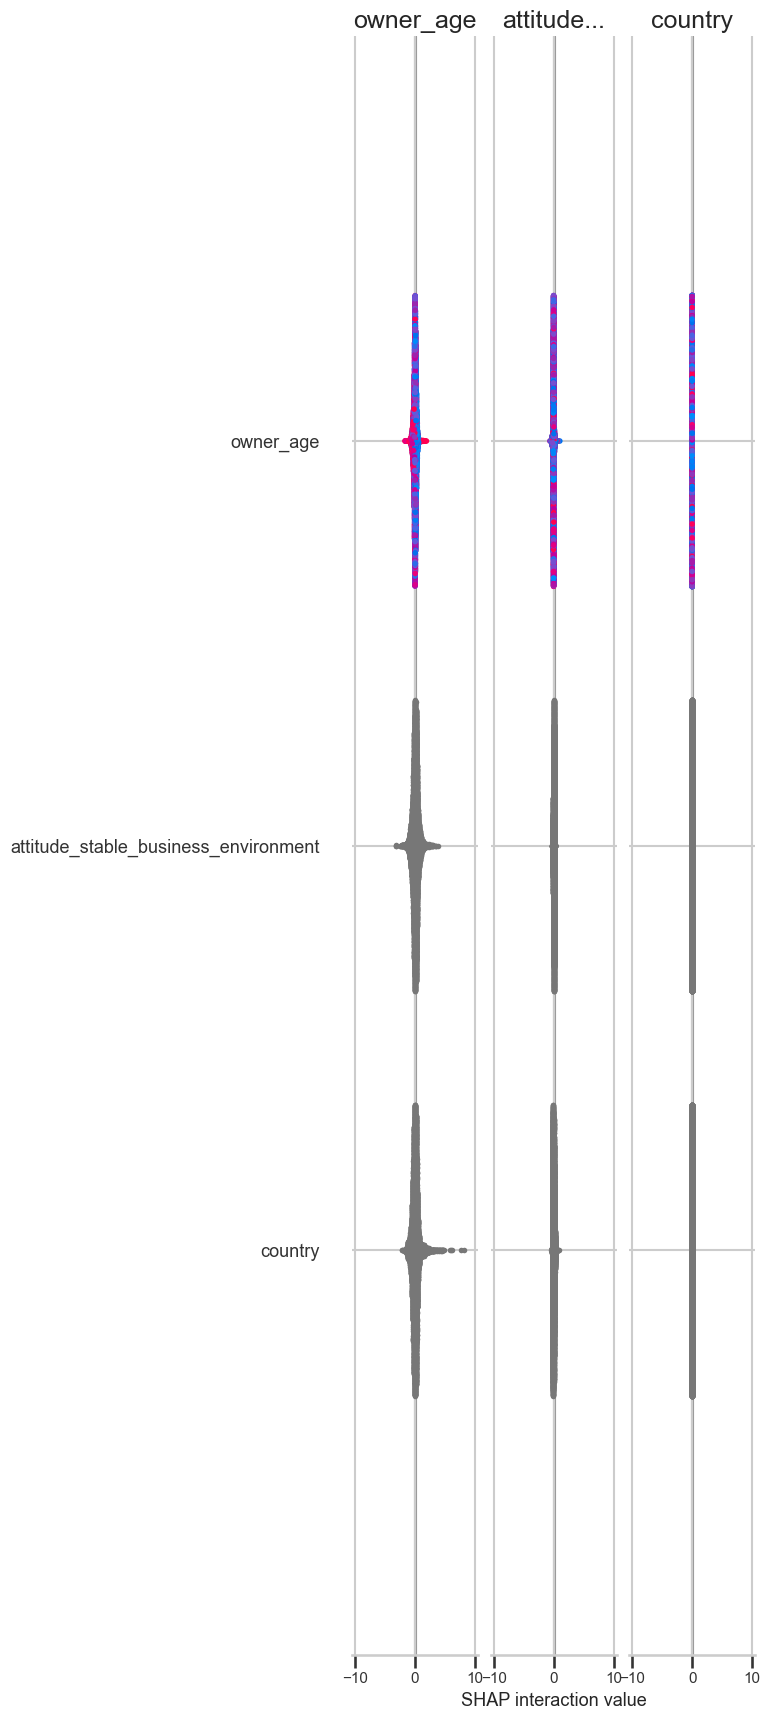

In [38]:
# true shap summary plot

shap.summary_plot(
    shap_values,
    X_corr_pruned,
    max_display=20
)

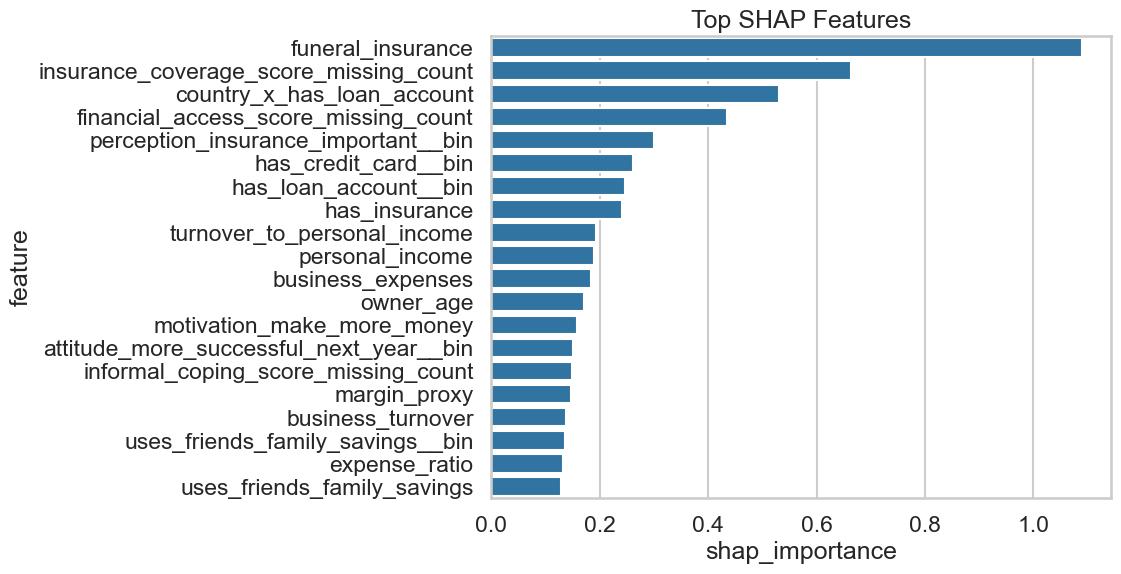

In [39]:
top = shap_df.head(20)

plt.figure(figsize=(8,6))
sns.barplot(data=top, y="feature", x="shap_importance")
plt.title("Top SHAP Features")
plt.show()

### Build Final Feature Ranking

Combine all signals:

+ Combined model importance

+ Permutation importance

+ SHAP importance

In [40]:
# Merge ranking

feature_rank = combined_importance.merge(
    perm_df,
    on="feature"
)

feature_rank = feature_rank.merge(
    shap_df,
    on="feature"
)

In [41]:
# Nromalize scores

for col in ["combined", "perm_importance", "shap_importance"]:
    feature_rank[col] = (
        feature_rank[col] - feature_rank[col].min()
    ) / (
        feature_rank[col].max() - feature_rank[col].min()
    )

In [42]:
# Final importance scores

feature_rank["final_score"] = (
    0.4 * feature_rank["combined"] +
    0.3 * feature_rank["perm_importance"] +
    0.3 * feature_rank["shap_importance"]
)

feature_rank = feature_rank.sort_values(
    "final_score",
    ascending=False
)

In [43]:
# Select final features 

top_features = feature_rank.head(80)["feature"].tolist()

X_final = X_corr_pruned[top_features]
test_final = test_fe[top_features]

### Rebuild Final Ensemble

We now rebuild the CatBoost + LightGBM blend.

In [44]:
# OOF Predictions 

oof_cat = np.zeros((len(X_final), 3))
oof_lgb = np.zeros((len(X_final), 3))

In [45]:
#Update categorical columns for cross validation training 

cat_cols_final = [col for col in cat_cols if col in X_final.columns]

In [46]:
# sanity checks

print("Features in final dataset:", len(X_final.columns))
print("Categorical features used:", cat_cols_final)

all(col in X_final.columns for col in cat_cols_final)

Features in final dataset: 80
Categorical features used: ['attitude_stable_business_environment', 'attitude_worried_shutdown', 'perception_insurance_doesnt_cover_losses', 'perception_cannot_afford_insurance', 'motor_vehicle_insurance', 'current_problem_cash_flow', 'has_cellphone', 'owner_sex', 'attitude_satisfied_with_achievement', 'has_credit_card', 'has_insurance', 'problem_sourcing_money', 'marketing_word_of_mouth', 'has_loan_account', 'has_debit_card', 'future_risk_theft_stock', 'medical_insurance', 'funeral_insurance', 'motivation_make_more_money', 'uses_friends_family_savings', 'country_x_resilience_risk_score', 'country_x_formality_score', 'country_x_business_confidence_score', 'country_x_has_loan_account']


True

In [47]:
# Cross validatopn training

for fold, (train_idx, val_idx) in enumerate(skf.split(X_final, y)):

    X_train, X_val = X_final.iloc[train_idx], X_final.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    cat_model = CatBoostClassifier(
        iterations=1500,
        learning_rate=0.03,
        depth=8,
        loss_function="MultiClass",
        verbose=False
    )

    cat_model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_cols_final
    )

    lgb_model = lgb.LGBMClassifier(
        n_estimators=1200,
        learning_rate=0.02,
        num_leaves=128
    )

    lgb_model.fit(
        X_train,
        y_train,
        categorical_feature=cat_cols_final
    )

    oof_cat[val_idx] = cat_model.predict_proba(X_val)
    oof_lgb[val_idx] = lgb_model.predict_proba(X_val)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001544 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3203
[LightGBM] [Info] Number of data points in the train set: 7694, number of used features: 80
[LightGBM] [Info] Start training from score -3.018607
[LightGBM] [Info] Start training from score -0.426214
[LightGBM] [Info] Start training from score -1.210144
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

In [48]:
# Blend Predictions Using best weights discovered earlier.
# CatBoost = 0.35
# LightGBM = 0.65

oof_blend = 0.35 * oof_cat + 0.65 * oof_lgb

In [49]:
#Encode the target

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

# Evaluate final OOF score

y_pred = np.argmax(oof_blend, axis=1)

final_f1 = f1_score(y_encoded, y_pred, average="macro")

print("Final OOF Macro F1:", final_f1)

Final OOF Macro F1: 0.7952178209762897


In [50]:
# Train final models on full data

cat_model.fit(X_final, y, cat_features=cat_cols_final)
lgb_model.fit(X_final, y, categorical_feature=cat_cols_final)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003490 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3213
[LightGBM] [Info] Number of data points in the train set: 9618, number of used features: 80
[LightGBM] [Info] Start training from score -3.018659
[LightGBM] [Info] Start training from score -0.426266
[LightGBM] [Info] Start training from score -1.210021
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

,boosting_type,'gbdt'
,num_leaves,128
,max_depth,-1
,learning_rate,0.02
,n_estimators,1200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [51]:
#save cat columns from training
cat_cols = X_train.select_dtypes(include="category").columns

#align test dataset categroies
for col in cat_cols:
    test_final[col] = test_final[col].astype("category")
    test_final[col] = test_final[col].cat.set_categories(X_train[col].cat.categories)
    
# Test predictions
test_cat = cat_model.predict_proba(test_final)
test_lgb = lgb_model.predict_proba(test_final)

In [52]:
# Blend test predictions

test_blend = 0.35 * test_cat + 0.65 * test_lgb

In [53]:
# final predcitions

final_preds = np.argmax(test_blend, axis=1)

In [54]:
#create submissions

submission = pd.DataFrame({
    "ID": test_fe["ID"],
    "target": final_preds
})

submission.to_csv("final_submission.csv", index=False)

In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.57      0.68       470
           1       0.89      0.96      0.92      6280
           2       0.83      0.74      0.78      2868

    accuracy                           0.87      9618
   macro avg       0.85      0.76      0.80      9618
weighted avg       0.87      0.87      0.87      9618



In [57]:
# verify files exist for download

print(X_final.shape)
print(y.shape)
print(type(cat_model))
print(type(lgb_model))

(9618, 80)
(9618,)
<class 'catboost.core.CatBoostClassifier'>
<class 'lightgbm.sklearn.LGBMClassifier'>


In [58]:
# save all outputs

import os
import pandas as pd
import joblib

# Create directories if they don’t exist
os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)

# =========================
# SAVE DATASETS
# =========================
X_final.to_pickle("data/X_final.pkl")
y.to_pickle("data/y.pkl")
test_final.to_pickle("data/test_final.pkl")

# =========================
# SAVE MODELS
# =========================
joblib.dump(cat_model, "models/catboost_final.pkl")
joblib.dump(lgb_model, "models/lightgbm_final.pkl")

# =========================
# SAVE PREDICTIONS
# =========================
pd.to_pickle(oof_blend, "models/oof_blend.pkl")
pd.to_pickle(final_preds, "models/final_preds.pkl")

print("✅ All files saved successfully.")

✅ All files saved successfully.


# Notebook 8: Feature Selection and Model Evaluation

## 1. Objective

The objective of this stage was to **analyze feature importance and reduce redundant predictors** in order to potentially improve model generalization, interpretability, and computational efficiency.

Although tree-based models such as **LightGBM** and **CatBoost** perform implicit feature selection during training, explicit feature selection was explored to determine whether removing weak or redundant variables could further improve predictive performance.

---

## 2. Feature Importance Analysis

To understand which predictors contributed most to the model’s decisions, **SHAP (SHapley Additive exPlanations)** values were computed.

SHAP provides a consistent framework for interpreting machine learning models by measuring **each feature's contribution to the model’s predictions**.

Key steps included:

- Computing SHAP values from the trained ensemble model  
- Aggregating mean absolute SHAP values across all observations  
- Ranking features based on their contribution to predictive performance  

This allowed identification of:

- Highly influential predictors  
- Low-impact features  
- Potentially redundant variables  

---

## 3. Correlation-Based Feature Pruning

After ranking features by importance, correlation analysis was conducted to identify **highly correlated predictors**.

Highly correlated features can introduce redundancy without improving predictive power.

The process included:

1. Computing the **correlation matrix** for all predictors  
2. Identifying feature pairs with high correlation  
3. Retaining the feature with **higher SHAP importance** while removing the less informative one  

This produced a **pruned feature set** designed to reduce redundancy while maintaining predictive signal.

---

## 4. Model Retraining with Selected Features

The ensemble model was retrained using the reduced feature set.

Two models were used:

- **CatBoost**
- **LightGBM**

Their predictions were combined through **blending**, where the optimal weight between models was selected using cross-validation.

The objective was to determine whether the **reduced feature space improved generalization performance**.

---

## 5. Model Performance Evaluation

Performance was evaluated using **Macro F1-score**, which is appropriate for imbalanced classification problems because it gives equal importance to each class.

### Classification Report (After Feature Selection)

| Class | Precision | Recall | F1-score | Support |
|------|------|------|------|------|
| High | 0.84 | 0.57 | 0.68 | 470 |
| Low | 0.89 | 0.96 | 0.92 | 6280 |
| Medium | 0.83 | 0.74 | 0.78 | 2868 |

**Overall metrics:**

- **Accuracy:** 0.87  
- **Macro F1:** 0.80  
- **Weighted F1:** 0.87  

---

## 6. Comparison with Previous Model

The results were compared with the model from **Notebook 7 (Model Enhancement & Ensembling)**.

| Metric | Notebook 7 | Notebook 8 |
|------|------|------|
| Accuracy | 0.88 | 0.87 |
| Macro F1 | 0.82 | 0.80 |

The model trained **without feature selection slightly outperformed the pruned model**.

The main difference was observed in the **minority class ("High")**, where recall dropped after feature removal.

This indicates that some removed features contained useful signals for detecting minority-class patterns.

---

## 7. Key Insights

Several important insights emerged from this analysis:

### 1. Tree-based models already perform effective internal feature selection

Algorithms such as **LightGBM** and **CatBoost** automatically ignore irrelevant predictors during training.

### 2. Aggressive feature pruning can harm minority-class detection

Some lower-ranked features may still capture **rare but important patterns**, particularly in imbalanced datasets.

### 3. Model simplicity must be balanced against predictive performance

While the pruned feature set reduced dimensionality, it did not improve overall performance.

---

## 8. Final Decision

Based on the evaluation results, the **full feature model from Notebook 7 was retained as the final production model**, as it achieved higher Macro F1 and better recall for the minority class.

Feature selection provided valuable **interpretability insights**, but it did not lead to performance improvements in this case.

---

## 9. Conclusion

This stage demonstrated the importance of **empirical evaluation when applying feature selection**.

While reducing feature dimensionality can improve model efficiency and interpretability, it does not always enhance predictive performance—particularly when using advanced ensemble algorithms that already manage feature importance internally.

The analysis confirmed that the **ensemble model using the full engineered feature set provided the best predictive performance for this task**.